In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

In [2]:
data_train_path = '1Train'
data_test_path = '2Test'
data_val_path = '3Validation'

In [3]:
img_width = 180
img_height =180 

In [4]:
data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_width, img_height),
    batch_size=32,
    validation_split=False)

Found 608 files belonging to 3 classes.


In [5]:
data_mild = data_train.class_names

In [6]:
data_mild

['Mild', 'Moderate', 'Severe']

In [7]:
data_val = tf.keras.utils.image_dataset_from_directory(data_val_path,
                                                       image_size=(img_height,img_width),
                                                       batch_size=32,
                                                        shuffle=False,
                                                       validation_split=False)

Found 141 files belonging to 3 classes.


In [8]:
data_test = tf.keras.utils.image_dataset_from_directory(
data_test_path,
    image_size=(img_height,img_width),
    shuffle=False,
    batch_size=32,
    validation_split=False
)

Found 151 files belonging to 3 classes.


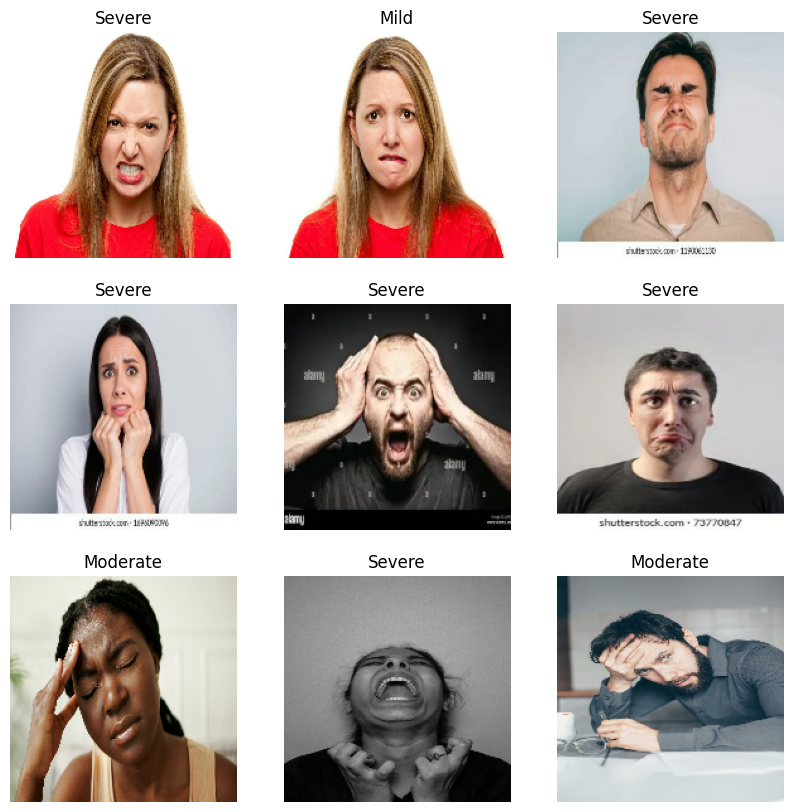

In [9]:
plt.figure(figsize=(10,10))
for image, labels in data_train.take(1):
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.title(data_mild[labels[i]])
        plt.axis('off')

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50, EfficientNetB0

In [11]:
# Load pre-trained ResNet50
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(180, 180, 3))
base_model_resnet.trainable = False  # Freeze the base
model_resnet = Sequential([    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax') # 3 classes: Mild, Moderate, Severe
])

model_resnet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [12]:
history = model_resnet.fit(
    data_train,
    validation_data=data_val,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3898 - loss: 1.5201 - val_accuracy: 0.4610 - val_loss: 1.0625
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.5477 - loss: 0.9430 - val_accuracy: 0.4184 - val_loss: 1.0794
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6118 - loss: 0.8570 - val_accuracy: 0.4255 - val_loss: 1.0960
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6579 - loss: 0.7771 - val_accuracy: 0.4681 - val_loss: 1.0854
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6595 - loss: 0.7648 - val_accuracy: 0.4326 - val_loss: 1.1640
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7286 - loss: 0.6480 - val_accuracy: 0.4326 - val_loss: 1.1779
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.7714 - loss: 0.5726 - val_accuracy: 0.4468 - val_loss: 1.1992
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7928 - loss: 0.5159 - val_accuracy: 0.4468 - val_loss:

In [13]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

# Load pre-trained ResNet50
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(180,180,3))

base_model_resnet.trainable = False

model_resnet = Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\dasun\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [15]:
import tensorflow as tf

In [16]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50

In [18]:
data_train_path = '1Train'
data_test_path = '2Test'
data_val_path = '3Validation'

img_width = 180
img_height = 180

data_train = tf.keras.utils.image_dataset_from_directory(
    data_train_path,
    shuffle=True,
    image_size=(img_height, img_width),
    batch_size=32
)

data_val = tf.keras.utils.image_dataset_from_directory(
    data_val_path,
    shuffle=False,
    image_size=(img_height, img_width),
    batch_size=32
)

data_test = tf.keras.utils.image_dataset_from_directory(
    data_test_path,
    shuffle=False,
    image_size=(img_height, img_width),
    batch_size=32
)

Found 608 files belonging to 3 classes.
Found 141 files belonging to 3 classes.
Found 151 files belonging to 3 classes.


In [19]:
base_model_resnet = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(180,180,3)
)

base_model_resnet.trainable = False

In [20]:
model_resnet = Sequential([
    base_model_resnet,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(3, activation='softmax')
])

In [21]:
model_resnet.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model_resnet.fit(
    data_train,
    validation_data=data_val,
    epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3931 - loss: 1.5608 - val_accuracy: 0.4113 - val_loss: 1.1334
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5197 - loss: 0.9577 - val_accuracy: 0.5035 - val_loss: 1.0578
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6250 - loss: 0.8343 - val_accuracy: 0.4043 - val_loss: 1.1610
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.6497 - loss: 0.7491 - val_accuracy: 0.4326 - val_loss: 1.1285
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.7451 - loss: 0.6445 - val_accuracy: 0.4681 - val_loss: 1.1319
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step - accuracy: 0.7484 - loss: 0.5974 - val_accuracy: 0.4468 - val_loss: 1.1591
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8010 - loss: 0.5269 - val_accuracy: 0.4539 - val_loss: 1.1422
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8158 - loss: 0.4836 - val_accuracy: 0.4397 - val_loss:

In [23]:
test_loss, test_acc = model_resnet.evaluate(data_test)
print("Test Accuracy:", test_acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 772ms/step - accuracy: 0.4702 - loss: 1.2336
Test Accuracy: 0.4701986610889435


In [24]:
model_resnet.save("stress_model_resnet.h5")

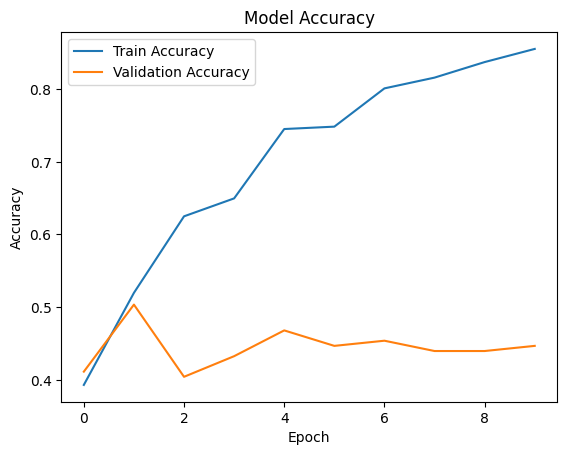

In [25]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])

plt.show()

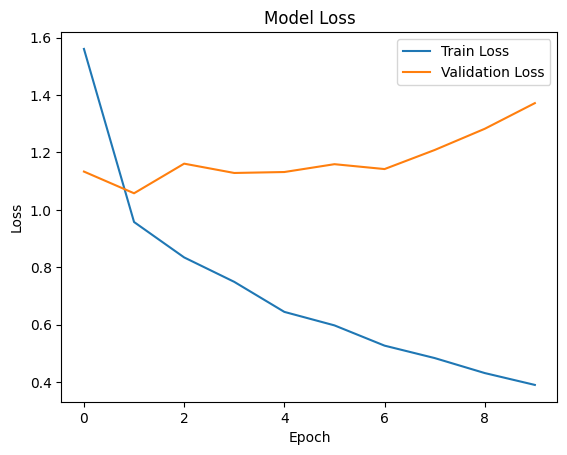

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])

plt.show()